# 03 - EDA Survey

**Fingo Income Predictor** | Tim CC26-PSU217

Input:
- `data/processed/survey_temporal_mapped.csv`
- `data/processed/survey_weekly_income_long.csv`

Output:
- Chart ke `outputs/charts/`
- Dashboard CSV ke `outputs/dashboard/`
- `outputs/reports/survey_eda_summary.md`

In [ ]:
# GIT PULL — Sinkronisasi terbaru dari remote sebelum mulai
import os, shutil, subprocess

try:
    from google.colab import userdata
except Exception:
    userdata = None

os.chdir("/content")

GITHUB_USERNAME = "ClarisyaA"
REPO_NAME       = "fingo-income-analysis"
BRANCH_NAME     = "feat/income-predictor-final"
LOCAL_DIR       = f"/content/{REPO_NAME}"
FRESH_CLONE     = False  # Set True hanya kalau mau clone ulang dari nol

def get_remote_url():
    try:
        token = userdata.get("GITHUB_TOKEN") if userdata else os.environ.get("GITHUB_TOKEN", "")
        if token:
            return f"https://{token}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git", token
    except Exception:
        pass
    return f"https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git", None

remote_url, token = get_remote_url()

def mask_cmd(cmd):
    return cmd.replace(token, "***TOKEN***") if token else cmd

def run_cmd(cmd, check=True, cwd="/content"):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=cwd)
    print(f"$ {mask_cmd(cmd)}")
    if r.stdout.strip(): print(r.stdout.strip())
    if r.stderr.strip(): print(r.stderr.strip())
    if check and r.returncode != 0:
        raise RuntimeError(f"Command gagal: {mask_cmd(cmd)}")
    return r

def remote_branch_exists():
    r = run_cmd(f"git ls-remote --heads {remote_url} {BRANCH_NAME}", check=False)
    return r.stdout.strip() != ""

branch_exists = remote_branch_exists()

if FRESH_CLONE and os.path.exists(LOCAL_DIR):
    os.chdir("/content")
    shutil.rmtree(LOCAL_DIR)

if not os.path.exists(LOCAL_DIR):
    if branch_exists:
        run_cmd(f"git clone -b {BRANCH_NAME} {remote_url} {LOCAL_DIR}")
    else:
        run_cmd(f"git clone {remote_url} {LOCAL_DIR}")
        run_cmd(f"git checkout -b {BRANCH_NAME}", cwd=LOCAL_DIR)
else:
    run_cmd(f"git remote set-url origin {remote_url}", cwd=LOCAL_DIR)
    run_cmd("git fetch origin", cwd=LOCAL_DIR)

    if branch_exists:
        local_b = run_cmd(f"git branch --list {BRANCH_NAME}", check=False, cwd=LOCAL_DIR).stdout.strip()
        if local_b:
            run_cmd(f"git checkout {BRANCH_NAME}", cwd=LOCAL_DIR)
        else:
            run_cmd(f"git checkout -b {BRANCH_NAME} origin/{BRANCH_NAME}", cwd=LOCAL_DIR)
        run_cmd(f"git pull --rebase origin {BRANCH_NAME}", cwd=LOCAL_DIR)
    else:
        current = run_cmd("git branch --show-current", check=False, cwd=LOCAL_DIR).stdout.strip()
        if current != BRANCH_NAME:
            local_b = run_cmd(f"git branch --list {BRANCH_NAME}", check=False, cwd=LOCAL_DIR).stdout.strip()
            if local_b:
                run_cmd(f"git checkout {BRANCH_NAME}", cwd=LOCAL_DIR)
            else:
                run_cmd(f"git checkout -b {BRANCH_NAME}", cwd=LOCAL_DIR)

os.chdir(LOCAL_DIR)
run_cmd(f"git remote set-url origin {remote_url}", cwd=LOCAL_DIR)
print("\n✓ Repo siap digunakan")
print(f"✓ Working directory: {os.getcwd()}")
run_cmd("git branch --show-current", cwd=LOCAL_DIR)
run_cmd("git status --short", check=False, cwd=LOCAL_DIR)

$ git ls-remote --heads https://***TOKEN***@github.com/ClarisyaA/fingo-income-analysis.git feat/income-predictor-final
af23ff52d210d5e5d7554a3d8abeff52a9bf67e7	refs/heads/feat/income-predictor-final
$ git remote set-url origin https://***TOKEN***@github.com/ClarisyaA/fingo-income-analysis.git
$ git fetch origin
$ git branch --list feat/income-predictor-final
* feat/income-predictor-final
$ git checkout feat/income-predictor-final
Your branch is up to date with 'origin/feat/income-predictor-final'.
Already on 'feat/income-predictor-final'
$ git pull --rebase origin feat/income-predictor-final
Already up to date.
From https://github.com/ClarisyaA/fingo-income-analysis
 * branch            feat/income-predictor-final -> FETCH_HEAD
$ git remote set-url origin https://***TOKEN***@github.com/ClarisyaA/fingo-income-analysis.git

✓ Repo siap digunakan
✓ Working directory: /content/fingo-income-analysis
$ git branch --show-current
feat/income-predictor-final
$ git status --short
?? outputs/char

CompletedProcess(args='git status --short', returncode=0, stdout='?? outputs/charts/eda_calendar_month_wom_relative_week.png\n', stderr='')

In [ ]:
import os, json, warnings, re, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="Set2")
except Exception:
    sns = None

warnings.filterwarnings("ignore")
os.chdir("/content/fingo-income-analysis")

IDR_FMT = mticker.FuncFormatter(lambda x, _: f"Rp {x/1e6:.1f}jt" if x >= 1e6 else f"Rp {x/1e3:.0f}rb")

def fmt_idr(val):
    if pd.isna(val): return "NaN"
    if val >= 1_000_000: return f"Rp {val/1_000_000:.2f}jt"
    return f"Rp {val/1_000:.0f}rb"

def ensure_dir(path):
    d = os.path.dirname(path) if "." in os.path.basename(path) else path
    if d: os.makedirs(d, exist_ok=True)

def safe_to_csv(df, path, **kwargs):
    ensure_dir(path)
    df.to_csv(path, index=kwargs.pop("index", False), **kwargs)
    return True

def safe_savefig(path, **kwargs):
    ensure_dir(path)
    plt.savefig(path, dpi=kwargs.pop("dpi", 150), bbox_inches="tight", **kwargs)

def safe_read_csv(path, **kwargs):
    for sep in [",", ";", "\t"]:
        try:
            df = pd.read_csv(path, sep=sep, **kwargs)
            if len(df.columns) > 1:
                return df
        except Exception:
            continue
    warnings.warn(f"[WARN] Gagal membaca {path}")
    return pd.DataFrame()

def find_file_by_keywords(folder, keywords):
    if not os.path.isdir(folder): return None
    for fname in os.listdir(folder):
        if all(kw.lower() in fname.lower() for kw in keywords):
            return os.path.join(folder, fname)
    return None

def get_week_of_month(date):
    """
    Week 1 = tanggal 1–7
    Week 2 = tanggal 8–14
    Week 3 = tanggal 15–21
    Week 4 = tanggal 22–28
    Week 5 = tanggal 29–31
    """
    if pd.isna(date): return np.nan
    return int((date.day - 1) // 7 + 1)

print("✓ Setup selesai")

ORDERED_GIG_TYPES = ["ojek_online", "kurir", "jualan_online", "freelance_desain",
                     "freelance_it", "content_creator", "tutor", "pekerja_harian"]

✓ Setup selesai


In [ ]:
# CELL 03.3 — Load data
df = pd.read_csv("data/processed/survey_temporal_mapped.csv")
df_long = pd.read_csv("data/processed/survey_weekly_income_long.csv")

if "timestamp_parsed" in df.columns:
    df["timestamp_parsed"] = pd.to_datetime(df["timestamp_parsed"], errors="coerce")

for dcol in ["period_start", "period_end"]:
    if dcol in df_long.columns:
        df_long[dcol] = pd.to_datetime(df_long[dcol], errors="coerce")

print(f"✓ survey_temporal_mapped: {df.shape}")
print(f"✓ survey_weekly_income_long: {df_long.shape}")
print(f"  Unique respondents long: {df_long['respondent_id'].nunique()}")

✓ survey_temporal_mapped: (384, 88)
✓ survey_weekly_income_long: (1536, 12)
  Unique respondents long: 384


## EDA — Distribusi Gig Type & Domisili

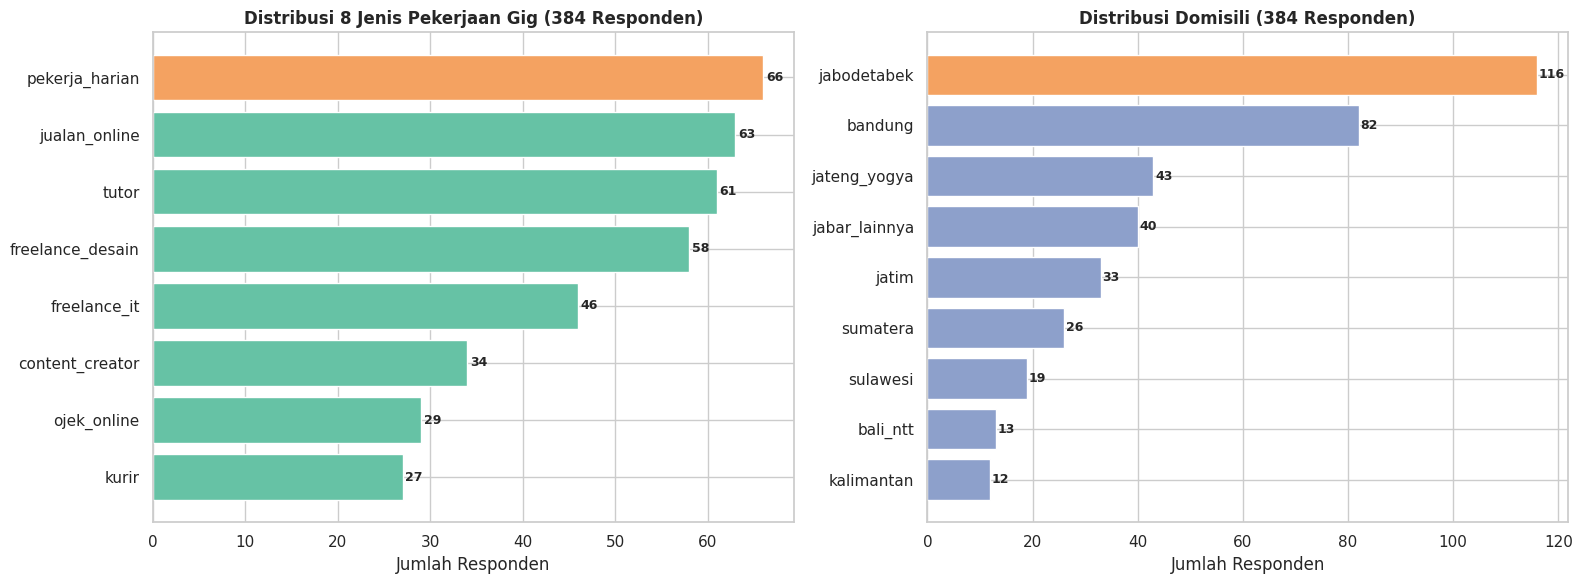

✓ Chart dan CSV distribusi gig_type & domisili berhasil disimpan.


In [ ]:
# CELL 03.4 — Distribusi gig_type dan domisili dengan warna highlight tertinggi

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =========================
# Helper
# =========================
def get_highlight_colors(values, base_color="#66C2A5", highlight_color="#F4A261"):
    max_value = values.max()
    return [highlight_color if v == max_value else base_color for v in values]

# =========================
# 1. Distribusi Gig Type
# =========================
gig_counts = df["gig_type"].value_counts().sort_values(ascending=True)
gig_colors = get_highlight_colors(
    gig_counts.values,
    base_color="#66C2A5",
    highlight_color="#F4A261"
)

axes[0].barh(gig_counts.index, gig_counts.values, color=gig_colors)
axes[0].set_title("Distribusi 8 Jenis Pekerjaan Gig (384 Responden)", fontweight="bold")
axes[0].set_xlabel("Jumlah Responden")

for i, v in enumerate(gig_counts.values):
    axes[0].text(
        v + 0.3,
        i,
        str(v),
        va="center",
        fontsize=9,
        fontweight="bold"
    )

# =========================
# 2. Distribusi Domisili
# =========================
dom_counts = df["domisili_code"].value_counts().sort_values(ascending=True)
dom_colors = get_highlight_colors(
    dom_counts.values,
    base_color="#8DA0CB",
    highlight_color="#F4A261"
)

axes[1].barh(dom_counts.index, dom_counts.values, color=dom_colors)
axes[1].set_title("Distribusi Domisili (384 Responden)", fontweight="bold")
axes[1].set_xlabel("Jumlah Responden")

for i, v in enumerate(dom_counts.values):
    axes[1].text(
        v + 0.3,
        i,
        str(v),
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
safe_savefig("outputs/charts/gig_type_distribution.png")
plt.show()

# =========================
# Save CSV
# =========================
safe_to_csv(
    gig_counts
    .reset_index()
    .rename(columns={"gig_type": "kategori", "index": "kategori", "count": "n"}),
    "outputs/dashboard/gig_type_distribution.csv"
)

safe_to_csv(
    dom_counts
    .reset_index()
    .rename(columns={"domisili_code": "kategori", "index": "kategori", "count": "n"}),
    "outputs/dashboard/domisili_distribution.csv"
)

print("✓ Chart dan CSV distribusi gig_type & domisili berhasil disimpan.")

## EDA — Income per Gig Type

=== Income Summary per Gig Type ===
        gig_type  n  avg_weekly  median_weekly  std_weekly    cv  avg_monthly
 content_creator 34    376961.0       298333.0    268475.0 0.134    1403676.0
freelance_desain 58    590453.0       532292.0    383663.0 0.134    2238448.0
    freelance_it 46    790018.0       682500.0    483436.0 0.130    2958804.0
   jualan_online 63    339325.0       315000.0    181672.0 0.129    1271190.0
           kurir 27    388753.0       385500.0     62509.0 0.187    1496556.0
     ojek_online 29    382382.0       366250.0    142748.0 0.147    1484931.0
  pekerja_harian 66    428125.0       392083.0    234103.0 0.131    1573864.0
           tutor 61    461954.0       382500.0    310884.0 0.141    1715492.0


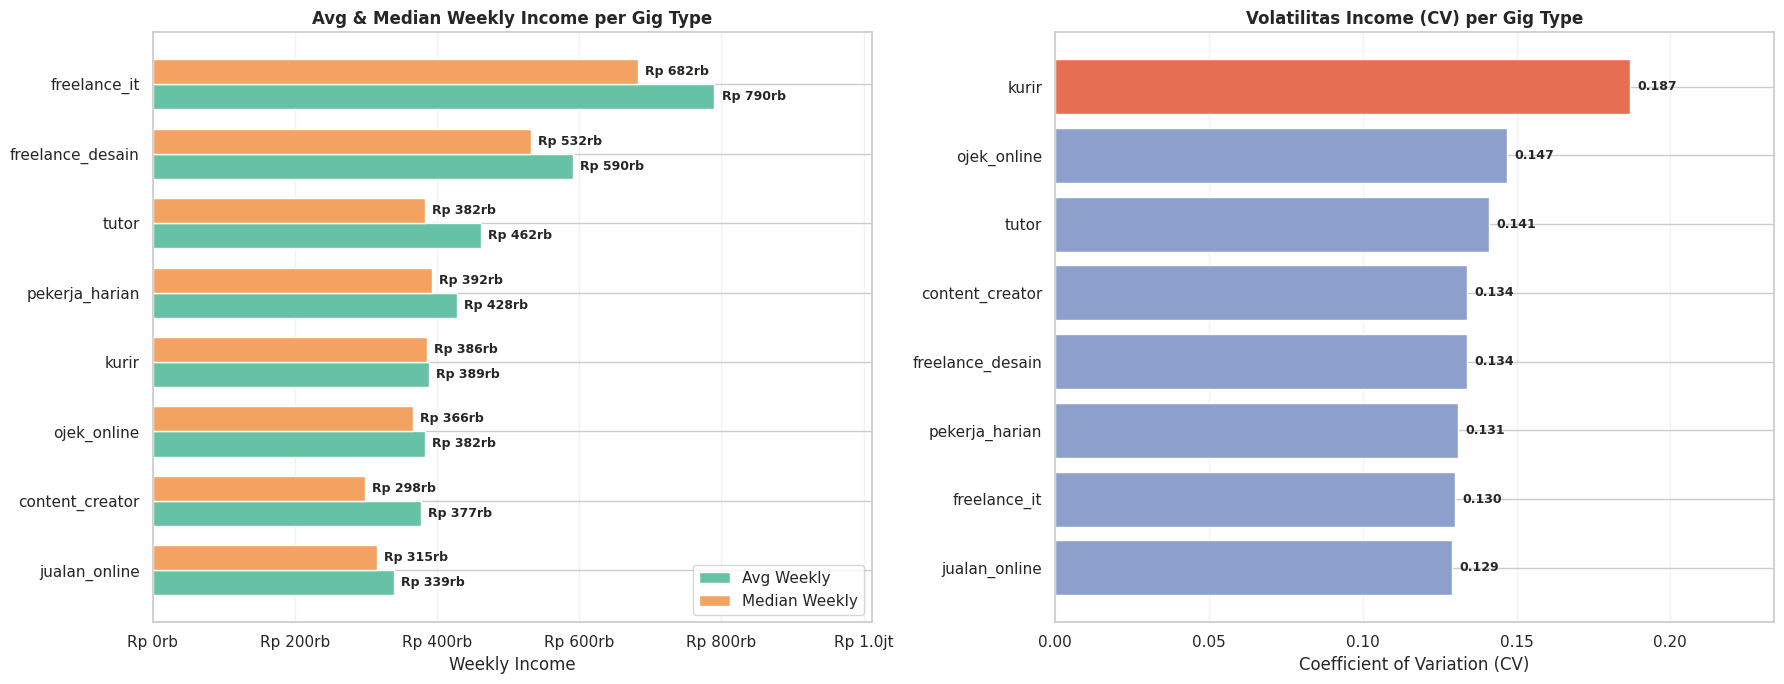

✓ Chart income_by_gig_type.png dan CSV real_4w_income_summary.csv berhasil disimpan.


In [ ]:
# CELL 03.5 — Income summary per gig_type dengan warna dan label yang jelas

import numpy as np

# =========================
# Income Summary
# =========================
gig_income_summary = df.groupby("gig_type").agg(
    n=("respondent_id", "count"),
    avg_weekly=("avg_weekly_income", "mean"),
    median_weekly=("avg_weekly_income", "median"),
    std_weekly=("avg_weekly_income", "std"),
    cv=("income_cv_4w", "mean"),
    avg_monthly=("monthly_income", "mean"),
).reset_index()

for c in ["avg_weekly", "median_weekly", "std_weekly", "avg_monthly"]:
    gig_income_summary[c] = gig_income_summary[c].round(0)

gig_income_summary["cv"] = gig_income_summary["cv"].round(3)

print("=== Income Summary per Gig Type ===")
print(gig_income_summary.to_string(index=False))

# =========================
# Helper
# =========================
def format_idr_short(value):
    if value >= 1_000_000:
        return f"Rp {value/1_000_000:.1f}jt"
    elif value >= 1_000:
        return f"Rp {value/1_000:.0f}rb"
    else:
        return f"Rp {value:.0f}"

def add_barh_labels(ax, bars, values, label_type="idr"):
    for bar, value in zip(bars, values):
        label = format_idr_short(value) if label_type == "idr" else f"{value:.3f}"
        ax.text(
            bar.get_width() + (ax.get_xlim()[1] * 0.01),
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            ha="left",
            fontsize=9,
            fontweight="bold"
        )

# =========================
# Plot Setup
# =========================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# =========================
# 1. Avg & Median Weekly Income
# =========================
sorted_df = gig_income_summary.sort_values("avg_weekly", ascending=True).copy()

y = np.arange(len(sorted_df))
bar_height = 0.36

avg_color = "#66C2A5"
median_color = "#F4A261"

bars_avg = axes[0].barh(
    y - bar_height / 2,
    sorted_df["avg_weekly"],
    height=bar_height,
    color=avg_color,
    label="Avg Weekly"
)

bars_median = axes[0].barh(
    y + bar_height / 2,
    sorted_df["median_weekly"],
    height=bar_height,
    color=median_color,
    label="Median Weekly"
)

axes[0].set_yticks(y)
axes[0].set_yticklabels(sorted_df["gig_type"])
axes[0].set_title("Avg & Median Weekly Income per Gig Type", fontweight="bold")
axes[0].set_xlabel("Weekly Income")
axes[0].xaxis.set_major_formatter(IDR_FMT)
axes[0].legend()

max_income = max(sorted_df["avg_weekly"].max(), sorted_df["median_weekly"].max())
axes[0].set_xlim(0, max_income * 1.28)

add_barh_labels(axes[0], bars_avg, sorted_df["avg_weekly"].values, label_type="idr")
add_barh_labels(axes[0], bars_median, sorted_df["median_weekly"].values, label_type="idr")

axes[0].grid(axis="x", alpha=0.25)

# =========================
# 2. Volatilitas CV per Gig Type
# =========================
cv_sorted = gig_income_summary.sort_values("cv", ascending=True).copy()

max_cv = cv_sorted["cv"].max()
cv_colors = [
    "#E76F51" if v == max_cv else "#8DA0CB"
    for v in cv_sorted["cv"]
]

bars_cv = axes[1].barh(
    cv_sorted["gig_type"],
    cv_sorted["cv"],
    color=cv_colors
)

axes[1].set_title("Volatilitas Income (CV) per Gig Type", fontweight="bold")
axes[1].set_xlabel("Coefficient of Variation (CV)")
axes[1].set_xlim(0, max_cv * 1.25)

add_barh_labels(axes[1], bars_cv, cv_sorted["cv"].values, label_type="cv")

axes[1].grid(axis="x", alpha=0.25)

plt.tight_layout()
safe_savefig("outputs/charts/income_by_gig_type.png")
plt.show()

# =========================
# Save CSV
# =========================
safe_to_csv(gig_income_summary, "outputs/dashboard/real_4w_income_summary.csv")

print("✓ Chart income_by_gig_type.png dan CSV real_4w_income_summary.csv berhasil disimpan.")

## EDA — Temporal: Relative Week, Calendar Month, Week of Month

=== Income per Relative Week ===
                   mean    median       std
relative_week                              
W4 (terlama)   447318.0  365000.0  350185.0
W3             443237.0  352500.0  333425.0
W2             455836.0  387500.0  344122.0
W1 (terbaru)   439378.0  355000.0  338448.0


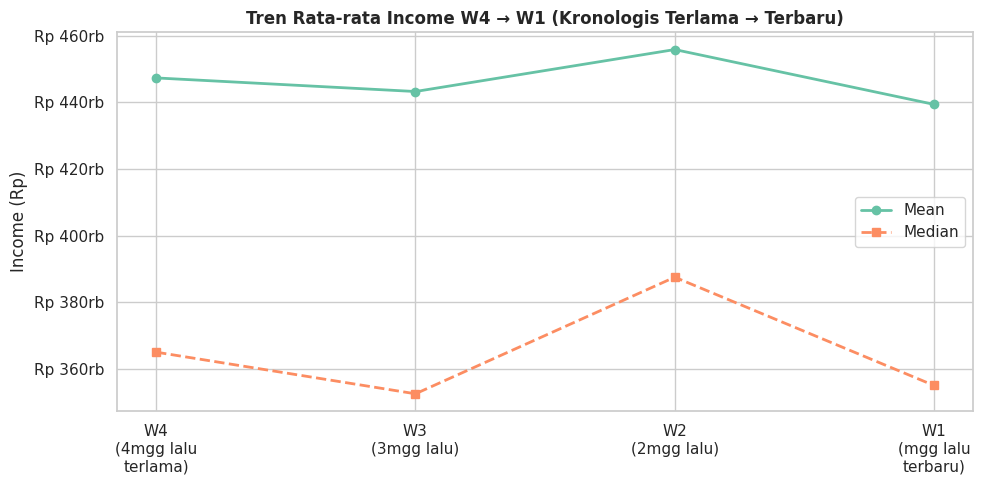

In [ ]:
# CELL 03.6 — Analisis relative_week (W4 terlama → W1 terbaru)
rw_summary = df_long.groupby("relative_week")["weekly_income"].agg(["mean","median","std"]).round(0)
rw_summary.index = rw_summary.index.map({-4:"W4 (terlama)",-3:"W3",-2:"W2",-1:"W1 (terbaru)"})
print("=== Income per Relative Week ===")
print(rw_summary.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
labels = ["W4\n(4mgg lalu\nterlama)", "W3\n(3mgg lalu)", "W2\n(2mgg lalu)", "W1\n(mgg lalu\nterbaru)"]
week_means   = [df[f"income_w{w}"].mean()   for w in [4, 3, 2, 1]]
week_medians = [df[f"income_w{w}"].median() for w in [4, 3, 2, 1]]
ax.plot(labels, week_means,   "o-", label="Mean",   linewidth=2)
ax.plot(labels, week_medians, "s--", label="Median", linewidth=2)
ax.set_title("Tren Rata-rata Income W4 → W1 (Kronologis Terlama → Terbaru)", fontweight="bold")
ax.set_ylabel("Income (Rp)")
ax.yaxis.set_major_formatter(IDR_FMT)
ax.legend()
plt.tight_layout()
safe_savefig("outputs/charts/weekly_income_trend_w4_to_w1.png")
plt.show()

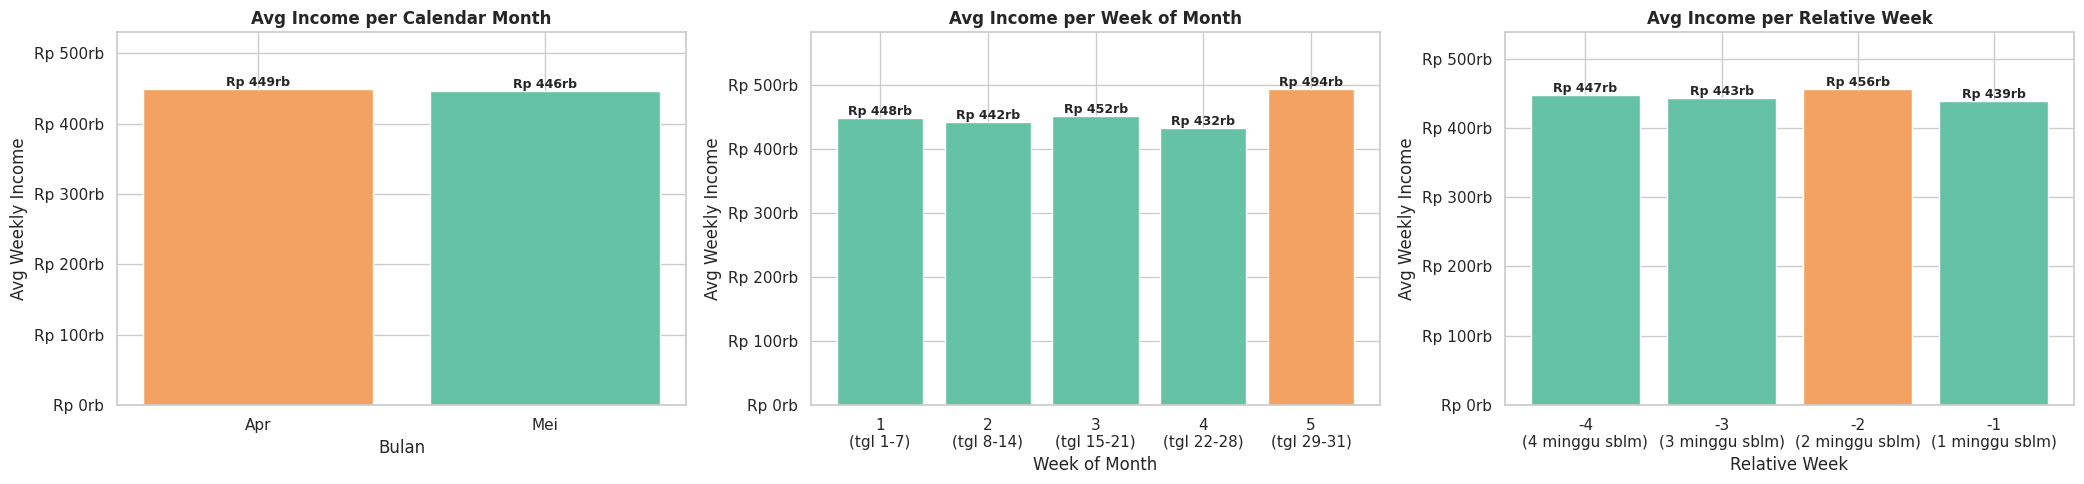

Income tertinggi di calendar_month: 4 (Apr)
Income tertinggi di week_of_month : 5
Income tertinggi di relative_week : -2
Makna relative_week -2: 2 minggu sebelum minggu acuan/target.


In [ ]:
# CELL 03.7 — Analisis calendar_month, week_of_month, dan relative_week

# =========================
# Data Cleaning
# =========================
needed_cols = ["calendar_month", "week_of_month", "relative_week", "weekly_income"]

missing_cols = [col for col in needed_cols if col not in df_long.columns]
if missing_cols:
    raise ValueError(f"Kolom berikut tidak ditemukan di df_long: {missing_cols}")

df_long_clean = df_long.dropna(subset=needed_cols).copy()

df_long_clean["calendar_month"] = df_long_clean["calendar_month"].astype(int)
df_long_clean["week_of_month"]  = df_long_clean["week_of_month"].astype(int)
df_long_clean["relative_week"]  = df_long_clean["relative_week"].astype(int)

# =========================
# Helper Function
# =========================
def format_idr_short(value):
    if value >= 1_000_000:
        return f"Rp {value/1_000_000:.1f}jt"
    elif value >= 1_000:
        return f"Rp {value/1_000:.0f}rb"
    else:
        return f"Rp {value:.0f}"

def add_bar_labels(ax, bars, values):
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            format_idr_short(value),
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

def get_peak_colors(index_values, peak_value):
    return ["#F4A261" if x == peak_value else "#66C2A5" for x in index_values]

# =========================
# Plot Setup
# =========================
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "Mei", 6: "Jun", 7: "Jul", 8: "Agu",
    9: "Sep", 10: "Okt", 11: "Nov", 12: "Des"
}

# =========================
# 1. Avg Income per Calendar Month
# =========================
cm_mean = (
    df_long_clean
    .groupby("calendar_month")["weekly_income"]
    .mean()
    .sort_index()
)

peak_month = cm_mean.idxmax()
month_colors = get_peak_colors(cm_mean.index, peak_month)

bars0 = axes[0].bar(cm_mean.index, cm_mean.values, color=month_colors)

axes[0].set_title("Avg Income per Calendar Month", fontweight="bold")
axes[0].set_xlabel("Bulan")
axes[0].set_ylabel("Avg Weekly Income")
axes[0].yaxis.set_major_formatter(IDR_FMT)

axes[0].set_xticks(cm_mean.index)
axes[0].set_xticklabels([month_names.get(m, str(m)) for m in cm_mean.index])

add_bar_labels(axes[0], bars0, cm_mean.values)

# Tambahkan ruang atas supaya label tidak kepotong
axes[0].set_ylim(0, cm_mean.max() * 1.18)

# =========================
# 2. Avg Income per Week of Month
# =========================
wom_mean = (
    df_long_clean
    .groupby("week_of_month")["weekly_income"]
    .mean()
    .sort_index()
)

peak_wom = wom_mean.idxmax()
wom_colors = get_peak_colors(wom_mean.index, peak_wom)

bars1 = axes[1].bar(wom_mean.index, wom_mean.values, color=wom_colors)

axes[1].set_title("Avg Income per Week of Month", fontweight="bold")
axes[1].set_xlabel("Week of Month")
axes[1].set_ylabel("Avg Weekly Income")
axes[1].yaxis.set_major_formatter(IDR_FMT)

axes[1].set_xticks(wom_mean.index)
axes[1].set_xticklabels([
    "1\n(tgl 1-7)" if int(w) == 1 else
    "2\n(tgl 8-14)" if int(w) == 2 else
    "3\n(tgl 15-21)" if int(w) == 3 else
    "4\n(tgl 22-28)" if int(w) == 4 else
    "5\n(tgl 29-31)"
    for w in wom_mean.index
])

add_bar_labels(axes[1], bars1, wom_mean.values)
axes[1].set_ylim(0, wom_mean.max() * 1.18)

# =========================
# 3. Avg Income per Relative Week
# =========================
rw_mean = (
    df_long_clean
    .groupby("relative_week")["weekly_income"]
    .mean()
    .sort_index()
)

peak_rw = rw_mean.idxmax()
rw_colors = get_peak_colors(rw_mean.index, peak_rw)

bars2 = axes[2].bar(rw_mean.index.astype(str), rw_mean.values, color=rw_colors)

axes[2].set_title("Avg Income per Relative Week", fontweight="bold")
axes[2].set_xlabel("Relative Week")
axes[2].set_ylabel("Avg Weekly Income")
axes[2].yaxis.set_major_formatter(IDR_FMT)

axes[2].set_xticks(range(len(rw_mean.index)))
axes[2].set_xticklabels([
    f"{rw}\n({abs(rw)} minggu sblm)" if rw < 0 else f"{rw}\n(minggu acuan)"
    for rw in rw_mean.index
])

add_bar_labels(axes[2], bars2, rw_mean.values)
axes[2].set_ylim(0, rw_mean.max() * 1.18)

# =========================
# Final Layout
# =========================
plt.tight_layout()
safe_savefig("outputs/charts/eda_calendar_month_wom_relative_week.png")
plt.show()

# =========================
# Peak Analysis
# =========================
print(f"Income tertinggi di calendar_month: {peak_month} ({month_names.get(peak_month, peak_month)})")
print(f"Income tertinggi di week_of_month : {peak_wom}")
print(f"Income tertinggi di relative_week : {peak_rw}")

if peak_rw < 0:
    print(f"Makna relative_week {peak_rw}: {abs(peak_rw)} minggu sebelum minggu acuan/target.")
elif peak_rw == 0:
    print(f"Makna relative_week {peak_rw}: minggu acuan/target.")
else:
    print(f"Makna relative_week {peak_rw}: {peak_rw} minggu setelah minggu acuan/target.")

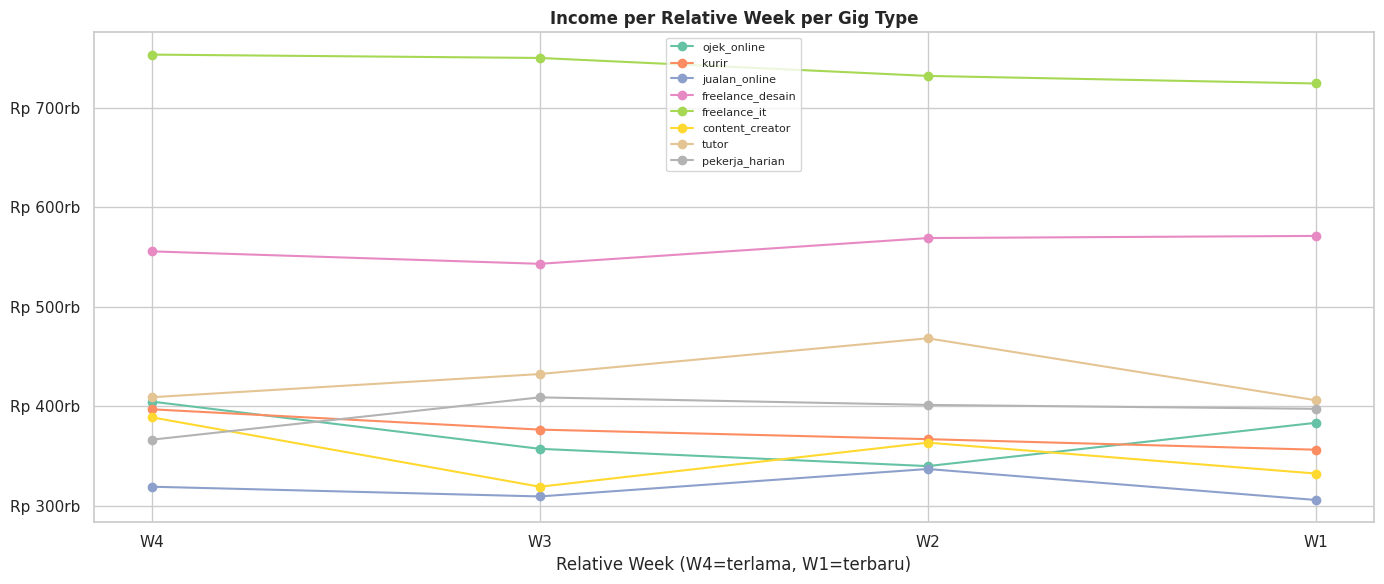

In [ ]:
# CELL 03.8 — Analisis per gig_type × relative_week
fig, ax = plt.subplots(figsize=(14, 6))
for gt in ORDERED_GIG_TYPES:
    sub = df_long[df_long["gig_type"] == gt].groupby("relative_week")["weekly_income"].mean()
    if len(sub) == 0:
        continue
    labels = [f"W{abs(rw)}" for rw in sorted(sub.index)]
    ax.plot(labels, [sub[rw] for rw in sorted(sub.index)], "o-", label=gt, linewidth=1.5)

ax.set_title("Income per Relative Week per Gig Type", fontweight="bold")
ax.set_xlabel("Relative Week (W4=terlama, W1=terbaru)")
ax.yaxis.set_major_formatter(IDR_FMT)
ax.legend(fontsize=8)
plt.tight_layout()
safe_savefig("outputs/charts/eda_income_rw_by_gig.png")
plt.show()

In [ ]:
# CELL 03.9 — Simpan EDA summary
ensure_dir("outputs/reports/")

insight_lines = []
rw_mean = df_long.groupby("relative_week")["weekly_income"].mean()
wom_mean = df_long.dropna(subset=["week_of_month"]).groupby("week_of_month")["weekly_income"].mean()
cm_mean  = df_long.dropna(subset=["calendar_month"]).groupby("calendar_month")["weekly_income"].mean()

insight_lines.append("# Survey EDA Summary — Fingo Income Predictor\n")
insight_lines.append("## Relative Week (W4=terlama, W1=terbaru)")
for rw in [-4,-3,-2,-1]:
    insight_lines.append(f"- W{abs(rw)}: mean={fmt_idr(rw_mean.get(rw,0))}")
insight_lines.append(f"\n**Income tertinggi di relative_week: W{abs(rw_mean.idxmax())}**")

insight_lines.append("\n## Week of Month (1=tgl1-7, ..., 5=tgl29-31)")
for w, v in wom_mean.items():
    insight_lines.append(f"- Week {int(w)}: mean={fmt_idr(v)}")
insight_lines.append(f"\n**Income tertinggi di week_of_month: {int(wom_mean.idxmax())}**")

insight_lines.append("\n## Calendar Month")
for m, v in cm_mean.items():
    insight_lines.append(f"- Bulan {int(m)}: mean={fmt_idr(v)}")

insight_lines.append("\n## Pola per Gig Type")
for gt in ORDERED_GIG_TYPES:
    sub_rw = df_long[df_long["gig_type"]==gt].groupby("relative_week")["weekly_income"].mean()
    if len(sub_rw):
        insight_lines.append(f"- {gt}: peak relative_week = W{abs(sub_rw.idxmax())}")

with open("outputs/reports/survey_eda_summary.md", "w", encoding="utf-8") as f:
    f.write("\n".join(insight_lines))

print("✓ Disimpan: outputs/reports/survey_eda_summary.md")

✓ Disimpan: outputs/reports/survey_eda_summary.md


In [ ]:
# GIT PUSH — Rewrite output lama dengan output notebook terbaru lalu push ke GitHub
import os
import subprocess
from google.colab import userdata

LOCAL_DIR   = "/content/fingo-income-analysis"
BRANCH_NAME = "feat/income-predictor-final"
NOTEBOOK_NAME = "03_EDA_Survey.ipynb"

# Folder/file yang mau di-rewrite di GitHub
REWRITE_PATHS = [
    "data",
    "outputs",
    "notebooks",
    NOTEBOOK_NAME,
]

os.chdir(LOCAL_DIR)

def run_cmd(cmd, check=True, hide_token=True):
    display_cmd = cmd

    if hide_token:
        try:
            token = userdata.get("GITHUB_TOKEN")
            if token:
                display_cmd = display_cmd.replace(token, "***TOKEN***")
        except Exception:
            pass

    print(f"$ {display_cmd}")

    r = subprocess.run(
        cmd,
        shell=True,
        capture_output=True,
        text=True
    )

    if r.stdout.strip():
        print(r.stdout.strip())

    if r.stderr.strip():
        err = r.stderr.strip()

        if hide_token:
            try:
                token = userdata.get("GITHUB_TOKEN")
                if token:
                    err = err.replace(token, "***TOKEN***")
            except Exception:
                pass

        print(err)

    if check and r.returncode != 0:
        raise RuntimeError(f"Command gagal: {display_cmd}")

    return r


# =========================
# 0. Setup Git Identity
# =========================
run_cmd('git config user.email "adelineclarisya@gmail.com"')
run_cmd('git config user.name "ClarisyaA"')


# =========================
# 1. Setup Remote dengan Token
# =========================
print("\n[1] Setup remote GitHub")

try:
    token = userdata.get("GITHUB_TOKEN")

    if not token:
        raise ValueError("GITHUB_TOKEN kosong / belum ada di Colab Secrets")

    remote_url = f"https://{token}@github.com/ClarisyaA/fingo-income-analysis.git"
    run_cmd(f'git remote set-url origin "{remote_url}"')

except Exception as e:
    print("[WARN] GITHUB_TOKEN tidak ditemukan atau bermasalah.")
    print("       Push bisa gagal kalau remote masih butuh autentikasi.")
    print(f"       Detail: {e}")


# =========================
# 2. Pastikan Branch Benar
# =========================
print("\n[2] Pastikan branch aktif benar")

current_branch = run_cmd("git branch --show-current", check=False).stdout.strip()

if current_branch != BRANCH_NAME:
    print(f"[INFO] Branch aktif sekarang: {current_branch}")
    print(f"[INFO] Pindah ke branch: {BRANCH_NAME}")

    run_cmd(f"git fetch origin {BRANCH_NAME}", check=False)

    checkout_result = run_cmd(f"git checkout {BRANCH_NAME}", check=False)

    if checkout_result.returncode != 0:
        run_cmd(f"git checkout -b {BRANCH_NAME} origin/{BRANCH_NAME}", check=False)


# =========================
# 3. Cek Status Awal
# =========================
print("\n[3] Status awal")
run_cmd("git status --short", check=False)


# =========================
# 4. Rewrite File Lama di Git Index
# =========================
print("\n[4] Hapus versi lama dari Git index")

for path in REWRITE_PATHS:
    run_cmd(f'git rm -r --cached --ignore-unmatch "{path}"', check=False)


# =========================
# 5. Add Ulang Versi Terbaru
# =========================
print("\n[5] Add ulang versi terbaru dari Colab")

for path in REWRITE_PATHS:
    if os.path.exists(path):
        run_cmd(f'git add -A "{path}"', check=False)
    else:
        print(f"[SKIP] Path tidak ditemukan di local: {path}")


# =========================
# 6. Cek Status Setelah Rewrite
# =========================
print("\n[6] Status setelah rewrite")
run_cmd("git status --short", check=False)


# =========================
# 7. Commit
# =========================
print("\n[7] Commit perubahan")

commit_msg = f'feat(DS2): rewrite output terbaru dari {NOTEBOOK_NAME}'

commit_result = run_cmd(
    f'git commit -m "{commit_msg}"',
    check=False
)

if commit_result.returncode != 0:
    print("[INFO] Tidak ada perubahan baru untuk di-commit.")
else:
    print("[OK] Commit berhasil dibuat.")


# =========================
# 8. Fetch Remote Terbaru
# =========================
print("\n[8] Fetch remote terbaru")
run_cmd("git fetch origin", check=False)


# =========================
# 9. Push Rewrite ke GitHub
# =========================
print("\n[9] Push ke GitHub dengan rewrite aman")

run_cmd(
    f"git push --force-with-lease -u origin {BRANCH_NAME}",
    check=True
)

print("\n✓ Push rewrite berhasil!")
print(f"✓ Branch remote sekarang mengikuti output terbaru dari: {NOTEBOOK_NAME}")
print(f"✓ Branch: {BRANCH_NAME}")

$ git config user.email "adelineclarisya@gmail.com"
$ git config user.name "ClarisyaA"

[1] Setup remote GitHub
$ git remote set-url origin "https://***TOKEN***@github.com/ClarisyaA/fingo-income-analysis.git"

[2] Pastikan branch aktif benar
$ git branch --show-current
feat/income-predictor-final

[3] Status awal
$ git status --short
?? outputs/charts/eda_calendar_month_wom_relative_week.png

[4] Hapus versi lama dari Git index
$ git rm -r --cached --ignore-unmatch "data"
rm 'data/processed/income_features.csv'
rm 'data/processed/survey_clean.csv'
rm 'data/processed/survey_temporal_mapped.csv'
rm 'data/processed/survey_weekly_income_long.csv'
rm 'data/raw/.gitkeep'
rm 'data/raw/Rata-Rata Pendapatan Bersih Sebulan Pekerja Bebas Menurut Provinsi dan Lapangan Pekerjaan Utama, 2025.csv'
rm 'data/raw/Rata-Rata Pendapatan Bersih Sebulan Pekerja Informal Menurut Provinsi dan Lapangan Pekerjaan Utama (rupiah), 2025.csv'
rm 'data/raw/Rata-Rata_Pendapatan_Bersih_Sebulan_Pekerja_Bebas_Menurut_Pro